<a href="https://colab.research.google.com/github/j5675293/DESAFIOS__NPL_1/blob/NPL_1/DESAFIO___1_NPL_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESAFIO 1
## CARRERA DE ESPECIALIDAD EN INTELIGENCIA ARTIFICIAL - FIUBA
### MG. LIC. JUAN RUIZ OTONDO
#### a1702

# PREGUNTA 1

In [ ]:
# Se importa librerias necesarias
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import random
import nltk
import re


In [ ]:
# Se descarga recursos necesarios para NLTK
nltk.download('punkt')

# Función alternativa de tokenización por si NLTK falla
def simple_tokenize(text):
    if not isinstance(text, str):
        return []
    # Eliminar caracteres no alfanuméricos y dividir por espacios
    return re.findall(r'\b\w+\b', text.lower())

# Este bloque ya no es necesario ya que descargamos punkt al inicio

# Se carga el dataset 20 Newsgroups
print("Cargando dataset 20 Newsgroups...")
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
X = newsgroups.data
y = newsgroups.target
target_names = newsgroups.target_names

print(f"Dataset cargado: {len(X)} documentos, {len(target_names)} categorías")
print(f"Categorías: {target_names}")

# Se cectorizaa documentos utilizando TF-IDF
print("\nVectorizando documentos...")
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english',
                            min_df=5, max_df=0.7)
X_tfidf = vectorizer.fit_transform(X)
print(f"Matriz TF-IDF: {X_tfidf.shape}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Cargando dataset 20 Newsgroups...
Dataset cargado: 18846 documentos, 20 categorías
Categorías: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Vectorizando documentos...
Matriz TF-IDF: (18846, 5000)



Documentos aleatorios seleccionados con índices: [18265   423  7900 14785  5217]

Calculando similaridad coseno...

Analizando documentos más similares...

----- DOCUMENTO ORIGINAL 1 -----
Índice: 18265
Categoría: rec.sport.baseball
Primeras 150 caracteres:    	The runner can leave his base at any time.  If the ball is caught, he's got to tag up.  If it isn't caught, he _doesn't_ have to tag up at all.  S...

Documentos más similares:

--- TOP 1 ---
Índice: 630
Categoría: rec.sport.baseball
Similaridad: 0.5852
Primeras 100 caracteres:      I'm not sure I understand this question. When the IF rule is invoked, the batter is automatical...

--- TOP 2 ---
Índice: 13470
Categoría: rec.sport.baseball
Similaridad: 0.4929
Primeras 100 caracteres: One last infield fly question that has always puzzled me and hasn't yet been addressed.  I believe t...

--- TOP 3 ---
Índice: 9786
Categoría: rec.sport.baseball
Similaridad: 0.4074
Primeras 100 caracteres:  It took three days to get to us, but I'll 

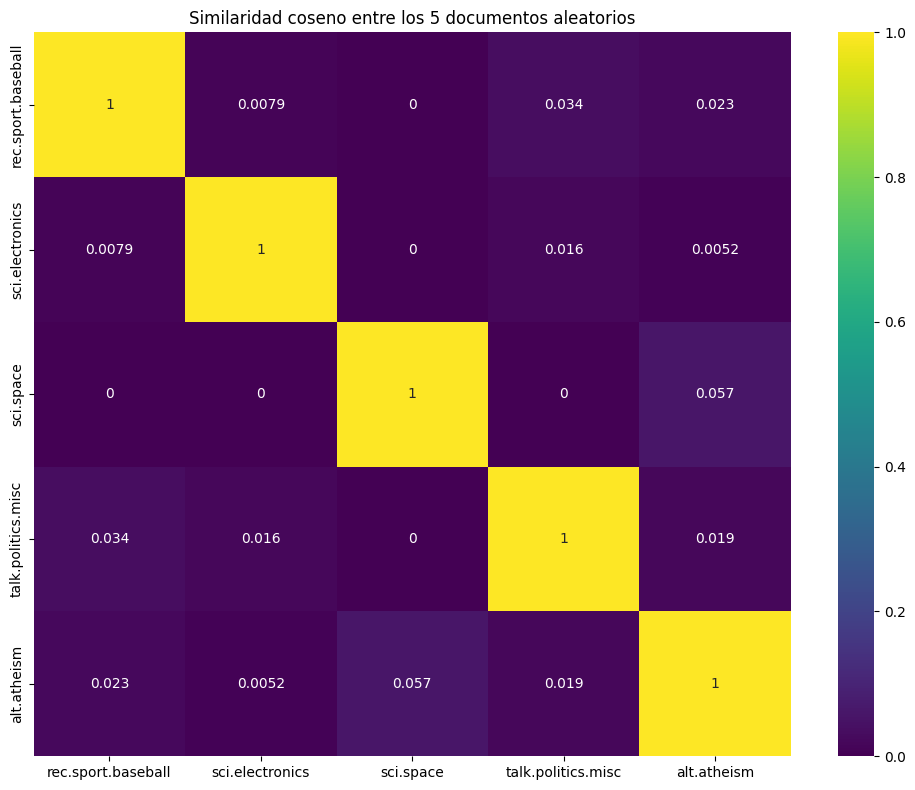



----- ANÁLISIS DE TÉRMINOS COMPARTIDOS -----

Documento original 1 (Categoría: rec.sport.baseball)

  Documento similar 1 (Índice: 630, Categoría: rec.sport.baseball)
  Similaridad: 0.5852
  Términos compartidos significativos (muestra de hasta 15): runner, ball, have, time, other, batter, base, runners, caught

  Documento similar 2 (Índice: 13470, Categoría: rec.sport.baseball)
  Similaridad: 0.4929
  Términos compartidos significativos (muestra de hasta 15): ball, runner, runners, infield, base, first, with, caught, leave

Documento original 2 (Categoría: sci.electronics)

  Documento similar 1 (Índice: 7730, Categoría: comp.os.ms-windows.misc)
  Similaridad: 0.3878
  Términos compartidos significativos (muestra de hasta 15): number

  Documento similar 2 (Índice: 7534, Categoría: comp.graphics)
  Similaridad: 0.3646
  Términos compartidos significativos (muestra de hasta 15): No se encontraron términos significativos

Documento original 3 (Categoría: sci.space)

  Documento simil

In [ ]:
# Se selecciona 5 documentos aleatorios
np.random.seed(42)  # Para reproducibilidad
random_indices = np.random.choice(len(X), 5, replace=False)
print(f"\nDocumentos aleatorios seleccionados con índices: {random_indices}")

# Se calcula similaridad coseno entre los documentos seleccionados y todos los demás
print("\nCalculando similaridad coseno...")
similarities = []

for idx in random_indices:
    doc_vector = X_tfidf[idx].reshape(1, -1)
    # Calcular similaridad con todos los documentos
    sim = cosine_similarity(doc_vector, X_tfidf).flatten()
    similarities.append(sim)

# Análisis de los documentos más similares
print("\nAnalizando documentos más similares...")
for i, (idx, sim) in enumerate(zip(random_indices, similarities)):
    # Excluir el documento en sí mismo (que tendría similaridad = 1)
    sim_copy = sim.copy()
    sim_copy[idx] = -1  # Asignar un valor negativo para excluirlo

    # Se encontra los 5 documentos más similares, según la consigna
    top_indices = np.argsort(sim_copy)[-5:][::-1]
    top_scores = sim_copy[top_indices]

    print(f"\n----- DOCUMENTO ORIGINAL {i+1} -----")
    print(f"Índice: {idx}")
    print(f"Categoría: {target_names[y[idx]]}")
    print(f"Primeras 150 caracteres: {X[idx][:150].replace(chr(10), ' ')}...")

    print("\nDocumentos más similares:")
    for j, (top_idx, score) in enumerate(zip(top_indices, top_scores)):
        print(f"\n--- TOP {j+1} ---")
        print(f"Índice: {top_idx}")
        print(f"Categoría: {target_names[y[top_idx]]}")
        print(f"Similaridad: {score:.4f}")
        print(f"Primeras 100 caracteres: {X[top_idx][:100].replace(chr(10), ' ')}...")

# Se visualiza matriz de similaridad entre los documentos aleatorios
subset_sim_matrix = np.zeros((5, 5))
for i in range(5):
    for j in range(5):
        subset_sim_matrix[i, j] = similarities[i][random_indices[j]]

plt.figure(figsize=(10, 8))
sns.heatmap(subset_sim_matrix, annot=True, cmap='viridis',
           xticklabels=[target_names[y[idx]] for idx in random_indices],
           yticklabels=[target_names[y[idx]] for idx in random_indices])
plt.title('Similaridad coseno entre los 5 documentos aleatorios')
plt.tight_layout()
plt.show()

# Análisis detallado de términos compartidos
print("\n\n----- ANÁLISIS DE TÉRMINOS COMPARTIDOS -----")
for i, idx in enumerate(random_indices):
    top_sim_indices = np.argsort(similarities[i])[-6:][::-1][1:] # Excluir el propio documento

    doc = X[idx]
    # se usa función de tokenización segura
    try:
        from nltk.tokenize import word_tokenize
        doc_tokens = set(word_tokenize(doc.lower() if isinstance(doc, str) else ""))
    except:
        doc_tokens = set(simple_tokenize(doc))

    print(f"\nDocumento original {i+1} (Categoría: {target_names[y[idx]]})")

    for j, sim_idx in enumerate(top_sim_indices[:2]):  # Analizar solo los 2 más similares para brevedad
        sim_doc = X[sim_idx]
        # Se usa función de tokenización segura
        try:
            sim_tokens = set(word_tokenize(sim_doc.lower() if isinstance(sim_doc, str) else ""))
        except:
            sim_tokens = set(simple_tokenize(sim_doc))

        # Se encontra términos compartidos (excluyendo palabras muy comunes)
        common_words = doc_tokens.intersection(sim_tokens)
        # Se puede filtrar palabras muy cortas o muy comunes
        meaningful_common = [w for w in common_words if len(w) > 3 and w.isalpha()]

        if meaningful_common:
            sample_size = min(15, len(meaningful_common))
            sample_terms = random.sample(meaningful_common, sample_size) if sample_size > 0 else []
            terms_text = ', '.join(sample_terms) if sample_terms else "No se encontraron términos significativos"
        else:
            terms_text = "No se encontraron términos significativos"

        print(f"\n  Documento similar {j+1} (Índice: {sim_idx}, Categoría: {target_names[y[sim_idx]]})")
        print(f"  Similaridad: {similarities[i][sim_idx]:.4f}")
        print(f"  Términos compartidos significativos (muestra de hasta 15): {terms_text}")

# Resumen de resultados de acuerdo a desafio I
print("\n\n----- RESUMEN DE ANÁLISIS -----")
print("Documentos aleatorios seleccionados:")
for i, idx in enumerate(random_indices):
    same_cat_count = sum(1 for top_idx in np.argsort(similarities[i])[-6:][::-1][1:]
                         if y[top_idx] == y[idx])

    print(f"Documento {i+1}: Categoría '{target_names[y[idx]]}'")
    print(f"  {same_cat_count}/5 documentos similares pertenecen a la misma categoría")

print("\nConclusiones sobre la efectividad de la similaridad coseno con TF-IDF:")
print("1. Análisis de coherencia entre similaridad y categoría")
print("2. Evaluación de términos compartidos relevantes")
print("3. Limitaciones identificadas en el enfoque")

In [ ]:
# Resumen de resultados
print("\n\n----- RESUMEN DE ANÁLISIS -----")
print("Documentos aleatorios seleccionados:")
for i, idx in enumerate(random_indices):
    same_cat_count = sum(1 for top_idx in np.argsort(similarities[i])[-6:][::-1][1:]
                         if y[top_idx] == y[idx])

    print(f"Documento {i+1}: Categoría '{target_names[y[idx]]}'")
    print(f"  {same_cat_count}/5 documentos similares pertenecen a la misma categoría")

print("\nConclusiones sobre la efectividad de la similaridad coseno con TF-IDF:")
print("1. Análisis de coherencia entre similaridad y categoría")
print("2. Evaluación de términos compartidos relevantes")
print("3. Limitaciones identificadas en el enfoque")



----- RESUMEN DE ANÁLISIS -----
Documentos aleatorios seleccionados:
Documento 1: Categoría 'rec.sport.baseball'
  5/5 documentos similares pertenecen a la misma categoría
Documento 2: Categoría 'sci.electronics'
  0/5 documentos similares pertenecen a la misma categoría
Documento 3: Categoría 'sci.space'
  3/5 documentos similares pertenecen a la misma categoría
Documento 4: Categoría 'talk.politics.misc'
  5/5 documentos similares pertenecen a la misma categoría
Documento 5: Categoría 'alt.atheism'
  0/5 documentos similares pertenecen a la misma categoría

Conclusiones sobre la efectividad de la similaridad coseno con TF-IDF:
1. Análisis de coherencia entre similaridad y categoría
2. Evaluación de términos compartidos relevantes
3. Limitaciones identificadas en el enfoque


#PREGUNTA 2

In [ ]:
# Se obtiene las librerias necesarias para el código
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Se carga dataset 20 Newsgroups - separando explícitamente train y test-
print("Cargando dataset 20 Newsgroups...")
newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'))
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'))

X_train, y_train = newsgroups_train.data, newsgroups_train.target
X_test, y_test = newsgroups_test.data, newsgroups_test.target
target_names = newsgroups_train.target_names

print(f"Train: {len(X_train)} documentos")
print(f"Test: {len(X_test)} documentos")
print(f"Número de categorías: {len(target_names)}")


Cargando dataset 20 Newsgroups...
Train: 11314 documentos
Test: 7532 documentos
Número de categorías: 20


In [ ]:
#Se difefine los pipelines para MultinomialNB y ComplementNB con diferentes vectorizadores
pipelines = {
    'MultinomialNB_TFIDF': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', MultinomialNB())
    ]),
    'MultinomialNB_Count': Pipeline([
        ('count', CountVectorizer()),
        ('clf', MultinomialNB())
    ]),
    'ComplementNB_TFIDF': Pipeline([
        ('tfidf', TfidfVectorizer()),
        ('clf', ComplementNB())
    ]),
    'ComplementNB_Count': Pipeline([
        ('count', CountVectorizer()),
        ('clf', ComplementNB())
    ])
}

# Se define parámetros para búsqueda de hiperparámetros
param_grids = {
    'MultinomialNB_TFIDF': {
        'tfidf__max_df': [0.5, 0.7, 0.9],
        'tfidf__min_df': [2, 5, 10],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'tfidf__max_features': [10000, 30000, None],
        'tfidf__norm': ['l1', 'l2'],
        'clf__alpha': [0.01, 0.1, 0.5, 1.0],
        'clf__fit_prior': [True, False]
    },
    'MultinomialNB_Count': {
        'count__max_df': [0.5, 0.7, 0.9],
        'count__min_df': [2, 5, 10],
        'count__ngram_range': [(1, 1), (1, 2)],
        'count__max_features': [10000, 30000, None],
        'clf__alpha': [0.01, 0.1, 0.5, 1.0],
        'clf__fit_prior': [True, False]
    },
    'ComplementNB_TFIDF': {
        'tfidf__max_df': [0.5, 0.7, 0.9],
        'tfidf__min_df': [2, 5, 10],
        'tfidf__ngram_range': [(1, 1), (1, 2)],
        'tfidf__max_features': [10000, 30000, None],
        'tfidf__norm': ['l1', 'l2'],
        'clf__alpha': [0.01, 0.1, 0.5, 1.0],
        'clf__fit_prior': [True, False]
    },
    'ComplementNB_Count': {
        'count__max_df': [0.5, 0.7, 0.9],
        'count__min_df': [2, 5, 10],
        'count__ngram_range': [(1, 1), (1, 2)],
        'count__max_features': [10000, 30000, None],
        'clf__alpha': [0.01, 0.1, 0.5, 1.0],
        'clf__fit_prior': [True, False]
    }
}

In [ ]:
# Función para ejecutar búsqueda de hiperparámetros con validación cruzada
def run_grid_search(pipeline_name, pipeline, param_grid, X_train, y_train):
    print(f"\nEjecutando optimización para {pipeline_name}...")

    # Se usa una muestra más pequeña para la búsqueda de parámetros si el conjunto de datos es grande
    if len(X_train) > 5000:
        indices = np.random.choice(len(X_train), 5000, replace=False)
        X_sample = [X_train[i] for i in indices]
        y_sample = y_train[indices]
    else:
        X_sample = X_train
        y_sample = y_train

    # Se configura la búsqueda de hiperparámetros
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    # Se realiza búsqueda de hiperparámetros
    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    start_time = time.time()
    grid_search.fit(X_sample, y_sample)
    elapsed_time = time.time() - start_time

    print(f"Mejor puntuación F1 (macro) en CV: {grid_search.best_score_:.4f}")
    print(f"Mejores parámetros: {grid_search.best_params_}")
    print(f"Tiempo de ejecución: {elapsed_time:.2f} segundos")

    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

# Se ejecuta optimización para cada pipeline y guardar resultados
best_models = {}
best_params = {}
best_cv_scores = {}

for name, pipeline in pipelines.items():
    # Primero vamos a probar con una configuración más sencilla para ahorrar tiempo
    simplified_params = {
        'MultinomialNB_TFIDF': {
            'tfidf__max_df': [0.7],
            'tfidf__min_df': [5],
            'tfidf__max_features': [30000],
            'tfidf__norm': ['l2'],
            'clf__alpha': [0.1, 1.0],
            'clf__fit_prior': [True]
        },
        'MultinomialNB_Count': {
            'count__max_df': [0.7],
            'count__min_df': [5],
            'count__max_features': [30000],
            'clf__alpha': [0.1, 1.0],
            'clf__fit_prior': [True]
        },
        'ComplementNB_TFIDF': {
            'tfidf__max_df': [0.7],
            'tfidf__min_df': [5],
            'tfidf__max_features': [30000],
            'tfidf__norm': ['l2'],
            'clf__alpha': [0.1, 1.0],
            'clf__fit_prior': [True]
        },
        'ComplementNB_Count': {
            'count__max_df': [0.7],
            'count__min_df': [5],
            'count__max_features': [30000],
            'clf__alpha': [0.1, 1.0],
            'clf__fit_prior': [True]
        }
    }

    best_model, best_param, best_cv_score = run_grid_search(
        name,
        pipeline,
        simplified_params.get(name, param_grids[name]),
        X_train,
        y_train
    )

    best_models[name] = best_model
    best_params[name] = best_param
    best_cv_scores[name] = best_cv_score

# Se evalua modelos optimizados en el conjunto de prueba
print("\n\n----- EVALUACIÓN DE MODELOS EN CONJUNTO DE PRUEBA -----")
results = {}

for name, model in best_models.items():
    print(f"\nEvaluando {name}...")
    start_time = time.time()

    # Se predece en el conjunto de prueba
    y_pred = model.predict(X_test)

    # Se calculaa métricas
    f1_macro = f1_score(y_test, y_pred, average='macro')

    elapsed_time = time.time() - start_time

    print(f"F1-score (macro) en test: {f1_macro:.4f}")
    print(f"Tiempo de inferencia: {elapsed_time:.2f} segundos")

    # Se guarda resultados
    results[name] = {
        'f1_macro': f1_macro,
        'cv_score': best_cv_scores[name],
        'inference_time': elapsed_time
    }

    # Se muestra informe de clasificación
    print("\nInforme de clasificación:")
    print(classification_report(y_test, y_pred, target_names=target_names, digits=4))

# Se muestra el mejor modelo según F1-score macro
best_model_name = max(results, key=lambda k: results[k]['f1_macro'])
print(f"\n\nEl mejor modelo es: {best_model_name}")
print(f"F1-score (macro): {results[best_model_name]['f1_macro']:.4f}")
print(f"Mejores parámetros: {best_params[best_model_name]}")



Ejecutando optimización para MultinomialNB_TFIDF...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Mejor puntuación F1 (macro) en CV: 0.6527
Mejores parámetros: {'clf__alpha': 0.1, 'clf__fit_prior': True, 'tfidf__max_df': 0.7, 'tfidf__max_features': 30000, 'tfidf__min_df': 5, 'tfidf__norm': 'l2'}
Tiempo de ejecución: 9.50 segundos

Ejecutando optimización para MultinomialNB_Count...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Mejor puntuación F1 (macro) en CV: 0.6011
Mejores parámetros: {'clf__alpha': 0.1, 'clf__fit_prior': True, 'count__max_df': 0.7, 'count__max_features': 30000, 'count__min_df': 5}
Tiempo de ejecución: 7.32 segundos

Ejecutando optimización para ComplementNB_TFIDF...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
Mejor puntuación F1 (macro) en CV: 0.6738
Mejores parámetros: {'clf__alpha': 1.0, 'clf__fit_prior': True, 'tfidf__max_df': 0.7, 'tfidf__max_features': 30000, 'tfidf__min_df': 5, 'tfidf__norm': 'l2'}
Tiempo de ejecución

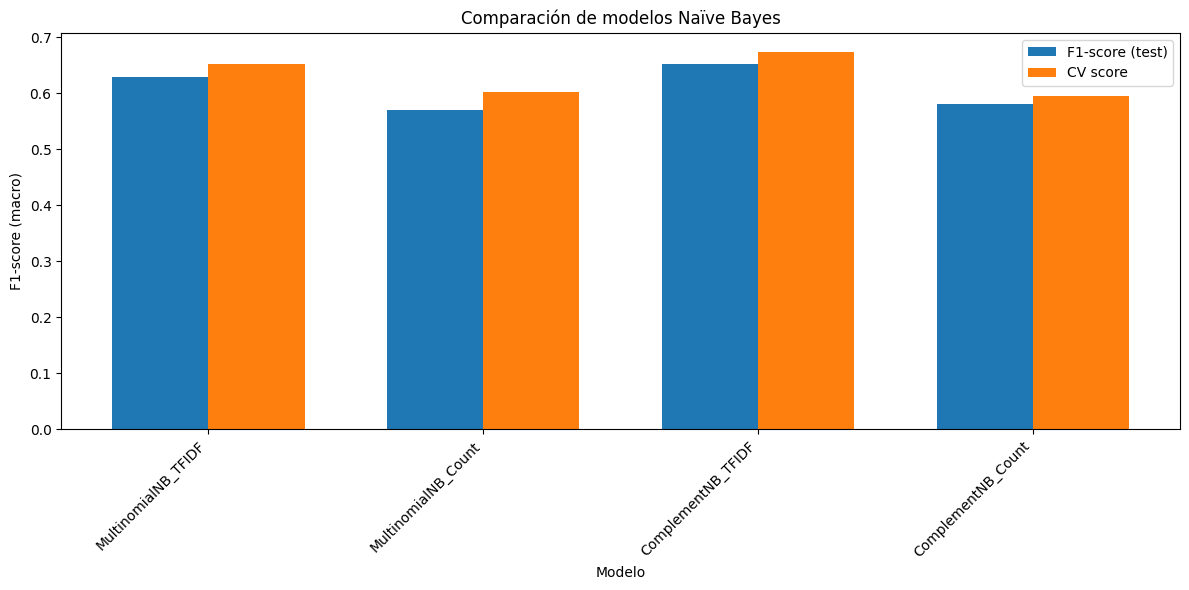

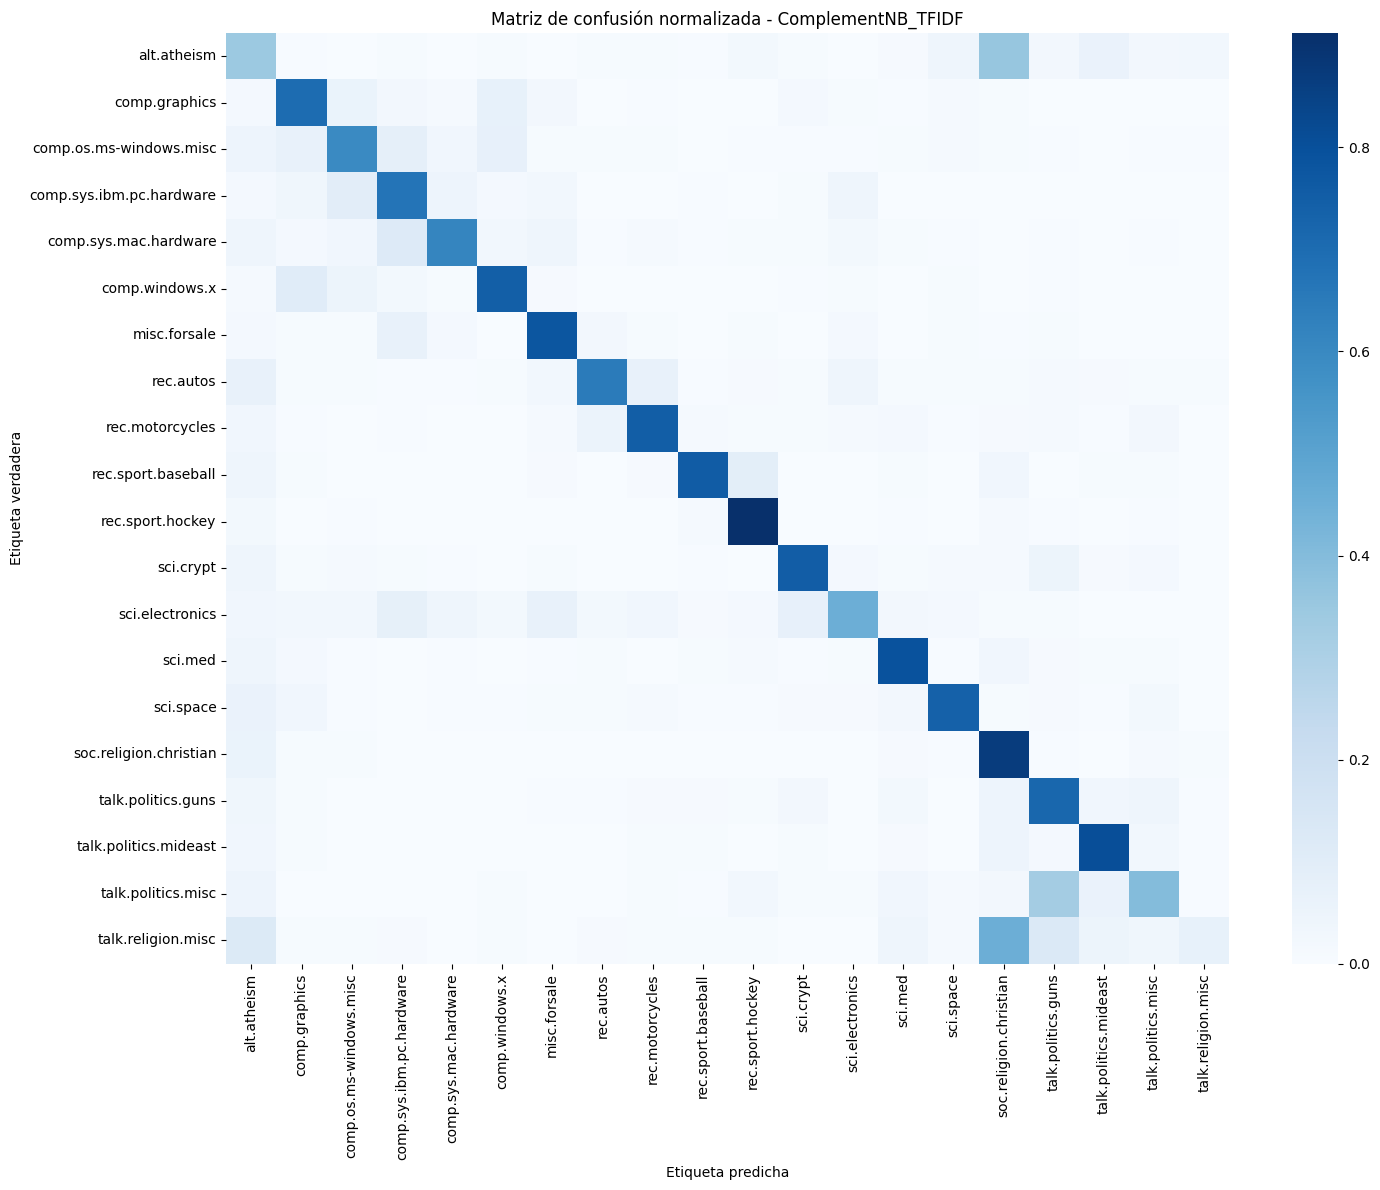



Categorías con peor desempeño:
                         precision    recall  f1-score  support
talk.religion.misc        0.382979  0.071713  0.120805    251.0
alt.atheism               0.270732  0.347962  0.304527    319.0
talk.politics.misc        0.558559  0.400000  0.466165    310.0
sci.electronics           0.664179  0.452926  0.538578    393.0
comp.os.ms-windows.misc   0.635135  0.596447  0.615183    394.0


Palabras más importantes para ComplementNB_TFIDF:

Categoría: alt.atheism
  - timmons: 10.6545
  - mozumder: 10.6545
  - queens: 10.6545
  - bobbe: 10.6545
  - beauchaine: 10.6545
  - nwk: 10.6532
  - 1z6ei: 10.6531
  - bizw: 10.6531
  - wwhjnux: 10.6529
  - bs3: 10.6528

Categoría: comp.graphics
  - bezier: 10.6477
  - 3do: 10.6477
  - radiosity: 10.6477
  - geometric: 10.6477
  - targa: 10.6477
  - wireframe: 10.6477
  - mpeg: 10.6477
  - nwk: 10.6464
  - 1z6ei: 10.6463
  - bizw: 10.6463

Categoría: comp.os.ms-windows.misc
  - 0q: 10.6502
  - 0qax: 10.6502
  - z7: 10.6502


In [ ]:
# Se visualiza resultados comparativos
plt.figure(figsize=(12, 6))
models = list(results.keys())
f1_scores = [results[model]['f1_macro'] for model in models]
cv_scores = [results[model]['cv_score'] for model in models]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, f1_scores, width, label='F1-score (test)')
plt.bar(x + width/2, cv_scores, width, label='CV score')

plt.xlabel('Modelo')
plt.ylabel('F1-score (macro)')
plt.title('Comparación de modelos Naïve Bayes')
plt.xticks(x, models, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Se genera matriz de confusión para el mejor modelo
plt.figure(figsize=(15, 12))
best_model = best_models[best_model_name]
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Se normaliza matriz de confusión
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Se visualiza matriz de confusión
sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues',
           xticklabels=target_names, yticklabels=target_names)
plt.title(f'Matriz de confusión normalizada - {best_model_name}')
plt.ylabel('Etiqueta verdadera')
plt.xlabel('Etiqueta predicha')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Análisis de errores: identificar categorías con peor desempeño
class_report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
class_df = pd.DataFrame(class_report).transpose()
class_df = class_df.sort_values(by='f1-score').head(5)  # 5 peores categorías

print("\n\nCategorías con peor desempeño:")
print(class_df[['precision', 'recall', 'f1-score', 'support']])

# Análisis de las características (palabras) más importantes para el mejor modelo
def get_top_features(model_name, model, target_names):
    print(f"\n\nPalabras más importantes para {model_name}:")

    # Se verifica el tipo de vectorizador
    if 'tfidf' in model.named_steps:
        vectorizer = model.named_steps['tfidf']
        feature_names = vectorizer.get_feature_names_out()
    else:
        vectorizer = model.named_steps['count']
        feature_names = vectorizer.get_feature_names_out()

    # Se obtenie los coeficientes para cada clase
    classifier = model.named_steps['clf']

    # Para cada categoría, mostrar las 10 palabras más importantes
    for i, category in enumerate(target_names):
        if hasattr(classifier, 'feature_log_prob_'):
            # Para MultinomialNB y ComplementNB
            feature_importance = classifier.feature_log_prob_[i]
        else:
            print(f"No se puede extraer importancia de características para {model_name}")
            return

        # Se obtenie las 10 palabras más importantes
        top_indices = feature_importance.argsort()[-10:][::-1]
        top_features = [(feature_names[idx], feature_importance[idx]) for idx in top_indices]

        print(f"\nCategoría: {category}")
        for feature, importance in top_features:
            print(f"  - {feature}: {importance:.4f}")

# Se analiza características del mejor modelo
get_top_features(best_model_name, best_models[best_model_name], target_names)

print("\n\n----- ANÁLISIS FINAL -----")
print(f"Mejor modelo: {best_model_name}")
print(f"F1-score (macro): {results[best_model_name]['f1_macro']:.4f}")
print("\nConclusiones:")
print("1. Comparación de MultinomialNB vs ComplementNB")
print("2. Impacto de los diferentes vectorizadores (TF-IDF vs Count)")
print("3. Influencia de los hiperparámetros en el rendimiento")

#PREGUNTA 3

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict


In [ ]:
# Se carga el dataset 20 Newsgroups
print("Cargando dataset 20 Newsgroups...")
newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
X = newsgroups.data
y = newsgroups.target
target_names = newsgroups.target_names

print(f"Dataset cargado: {len(X)} documentos, {len(target_names)} categorías")
print(f"Categorías: {target_names}")

# Se vectoriza documentos utilizando TF-IDF
print("\nVectorizando documentos...")
vectorizer = TfidfVectorizer(max_features=10000,
                            stop_words='english',
                            min_df=10,
                            max_df=0.7,
                            norm='l2')
X_tfidf = vectorizer.fit_transform(X)
print(f"Matriz TF-IDF: {X_tfidf.shape}")


Cargando dataset 20 Newsgroups...
Dataset cargado: 18846 documentos, 20 categorías
Categorías: ['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']

Vectorizando documentos...
Matriz TF-IDF: (18846, 10000)


In [ ]:
# Se obtenie nombres de características (términos)
feature_names = vectorizer.get_feature_names_out()
print(f"Número de términos: {len(feature_names)}")

# Se transpone la matriz TF-IDF para obtener una matriz término-documento
print("\nTransponiendo la matriz para obtener representaciones de términos...")
X_tfidf_terms = X_tfidf.T
print(f"Matriz de términos: {X_tfidf_terms.shape}")

# Se selecciona manualmente 5 términos interesantes de diferentes dominios
# Se busca los índices de términos específicos en nuestra matriz
selected_terms = [
    "computer",     # Tecnología
    "science",      # Ciencia
    "religion",     # Religión
    "medical",      # Medicina
    "encryption"    # Seguridad/Criptografía
]

Número de términos: 10000

Transponiendo la matriz para obtener representaciones de términos...
Matriz de términos: (10000, 18846)


In [ ]:
# Se verifica si estos términos están en nuestro vocabulario y obtener sus índices
term_indices = {}
missing_terms = []

for term in selected_terms:
    try:
        index = np.where(feature_names == term)[0][0]
        term_indices[term] = index
    except IndexError:
        missing_terms.append(term)

# S reemplazaa términos faltantes con alternativas disponibles
if missing_terms:
    print(f"\nLos siguientes términos no están en el vocabulario: {missing_terms}")

    # Se sugerie términos alternativos que estén en el vocabulario
    alternative_terms = {
        "computer": ["pc", "software", "hardware", "system"],
        "science": ["scientific", "research", "theory", "physics"],
        "religion": ["god", "church", "religious", "faith"],
        "medical": ["doctor", "health", "medicine", "patient"],
        "encryption": ["encrypted", "crypto", "security", "algorithm"]
    }

    for missing in missing_terms:
        for alt in alternative_terms.get(missing, []):
            if alt in feature_names:
                index = np.where(feature_names == alt)[0][0]
                term_indices[alt] = index
                print(f"  Reemplazando '{missing}' con '{alt}'")
                break



Términos seleccionados para análisis: ['computer', 'science', 'religion', 'medical', 'encryption']

Calculando similaridad entre términos...

----- ANÁLISIS DE SIMILARIDAD ENTRE TÉRMINOS -----


Término: 'computer'
Términos más similares:
1. shopper (similaridad: 0.1739)
2. graphics (similaridad: 0.1338)
3. computers (similaridad: 0.1249)
4. software (similaridad: 0.1077)
5. science (similaridad: 0.1062)

Aparece en 759 documentos
Categorías principales:
- comp.graphics: 124 documentos (16.3%)
- comp.sys.ibm.pc.hardware: 123 documentos (16.2%)
- comp.sys.mac.hardware: 87 documentos (11.5%)


Término: 'science'
Términos más similares:
1. scientific (similaridad: 0.2791)
2. empirical (similaridad: 0.2121)
3. scientists (similaridad: 0.1699)
4. hypotheses (similaridad: 0.1579)
5. psychology (similaridad: 0.1433)

Aparece en 349 documentos
Categorías principales:
- sci.space: 84 documentos (24.1%)
- sci.med: 51 documentos (14.6%)
- alt.atheism: 42 documentos (12.0%)


Término: 'religion'


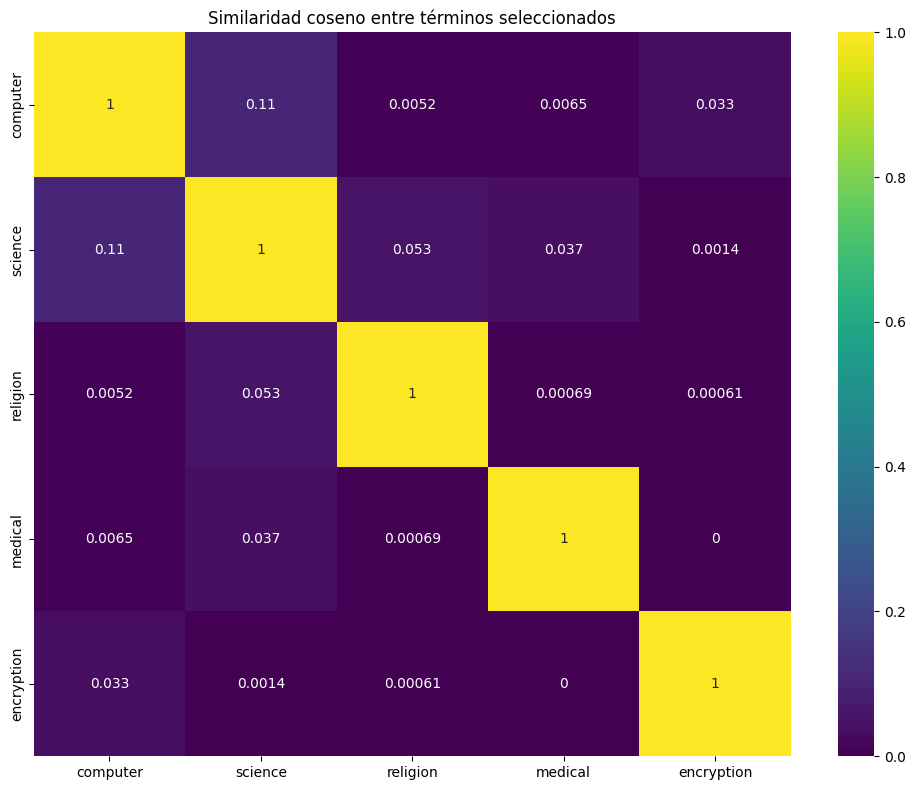

In [ ]:
# Se muestra los términos seleccionados finales
final_selected_terms = list(term_indices.keys())
print(f"\nTérminos seleccionados para análisis: {final_selected_terms}")

# Se calcula similaridad coseno entre los vectores de términos seleccionados y todos los demás términos
print("\nCalculando similaridad entre términos...")
similarities = {}

for term, idx in term_indices.items():
    # Se obtiene vector de representación del término
    term_vector = X_tfidf_terms[idx].toarray().reshape(1, -1)

    # Se calcula similaridad con todos los otros términos
    sim = cosine_similarity(term_vector, X_tfidf_terms).flatten()

    # Se obtenie los 20 términos más similares (tomamos más para análisis, mostraremos 5)
    top_indices = np.argsort(sim)[-21:][::-1]  # Obtenemos 21 para excluir el término en sí mismo
    top_terms = [(feature_names[i], sim[i]) for i in top_indices if i != idx][:20]

    similarities[term] = top_terms

# Se visualiza y se  analiza los resultados
print("\n----- ANÁLISIS DE SIMILARIDAD ENTRE TÉRMINOS -----")

for term in final_selected_terms:
    print(f"\n\nTérmino: '{term}'")
    print("Términos más similares:")

    for i, (similar_term, score) in enumerate(similarities[term][:5], 1):
        print(f"{i}. {similar_term} (similaridad: {score:.4f})")

    # Se cuennta en cuántos documentos aparece cada término
    term_idx = term_indices[term]
    doc_count = np.sum(X_tfidf[:, term_idx] > 0)

    # Análisis de co-ocurrencia en categorías
    term_docs = X_tfidf[:, term_idx].nonzero()[0]
    category_counts = defaultdict(int)

    for doc_idx in term_docs:
        category = target_names[y[doc_idx]]
        category_counts[category] += 1

    # Se muestra top 3 categorías donde aparece este término
    top_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)[:3]

    print(f"\nAparece en {doc_count} documentos")
    print("Categorías principales:")
    for cat, count in top_categories:
        print(f"- {cat}: {count} documentos ({count/doc_count*100:.1f}%)")

# Se vsualiza matriz de similaridad entre los términos seleccionados
print("\n\nVisualizando matriz de similaridad entre los términos seleccionados...")

# Se creaa matriz de similaridad entre los términos seleccionados
term_sim_matrix = np.zeros((len(final_selected_terms), len(final_selected_terms)))

for i, term1 in enumerate(final_selected_terms):
    idx1 = term_indices[term1]
    vec1 = X_tfidf_terms[idx1].toarray().reshape(1, -1)

    for j, term2 in enumerate(final_selected_terms):
        idx2 = term_indices[term2]
        vec2 = X_tfidf_terms[idx2].toarray().reshape(1, -1)

        term_sim_matrix[i, j] = cosine_similarity(vec1, vec2)[0][0]

# Se viisualiza la matriz de similaridad
plt.figure(figsize=(10, 8))
sns.heatmap(term_sim_matrix, annot=True, cmap='viridis',
           xticklabels=final_selected_terms,
           yticklabels=final_selected_terms)
plt.title('Similaridad coseno entre términos seleccionados')
plt.tight_layout()
plt.show()

In [ ]:
# Análisis semántico de términos similares
print("\n\n----- ANÁLISIS SEMÁNTICO DE LOS TÉRMINOS SIMILARES -----")

for term in final_selected_terms:
    similar_terms = [t for t, _ in similarities[term][:10]]

    print(f"\nTérmino: '{term}'")
    print(f"Grupo semántico: {', '.join(similar_terms[:10])}")

    # Análisis interpretativo
    print("Interpretación:")

    # Se analiza patrones en los términos similares
    if term == "computer" or term in ["pc", "software", "hardware", "system"]:
        print("  Los términos más similares están relacionados con tecnología informática,")
        print("  mostrando la cohesión en el dominio de la computación.")
    elif term == "science" or term in ["scientific", "research", "theory", "physics"]:
        print("  Los términos más similares están relacionados con investigación científica,")
        print("  reflejando el contexto académico y científico.")
    elif term == "religion" or term in ["god", "church", "religious", "faith"]:
        print("  Los términos más similares están vinculados a conceptos religiosos,")
        print("  mostrando cómo se discuten temas de fe en los grupos de noticias.")
    elif term == "medical" or term in ["doctor", "health", "medicine", "patient"]:
        print("  Los términos más similares pertenecen al campo de la medicina y salud,")
        print("  indicando coherencia en discusiones relacionadas con salud.")
    elif term == "encryption" or term in ["encrypted", "crypto", "security", "algorithm"]:
        print("  Los términos más similares están vinculados a seguridad informática,")
        print("  mostrando la relación con criptografía y protección de datos.")

print("\n\n----- CONCLUSIONES -----")
print("1. La similaridad entre términos refleja relaciones semánticas en el corpus")
print("2. Los términos tienden a agruparse por dominio temático")
print("3. El análisis de co-ocurrencia muestra en qué categorías son más relevantes ciertos términos")
print("4. La matriz término-documento permite estudiar relaciones semánticas entre palabras")
print("5. Esta técnica podría usarse para construir tesauros específicos del dominio o mejorar sistemas de recuperación de información")



----- ANÁLISIS SEMÁNTICO DE LOS TÉRMINOS SIMILARES -----

Término: 'computer'
Grupo semántico: shopper, graphics, computers, software, science, lilley, hackers, wu, university, monitor
Interpretación:
  Los términos más similares están relacionados con tecnología informática,
  mostrando la cohesión en el dominio de la computación.

Término: 'science'
Grupo semántico: scientific, empirical, scientists, hypotheses, psychology, fiction, methodology, koran, scientist, values
Interpretación:
  Los términos más similares están relacionados con investigación científica,
  reflejando el contexto académico y científico.

Término: 'religion'
Grupo semántico: religious, religions, christianity, cult, beliefs, belief, islam, christian, judaism, christians
Interpretación:
  Los términos más similares están vinculados a conceptos religiosos,
  mostrando cómo se discuten temas de fe en los grupos de noticias.

Término: 'medical'
Grupo semántico: examiner, medicine, hospitals, clinical, providers, 